In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def run_simulation(n_bandits, n_arms, n_steps, eps1, eps2, eps3):

    # Values selected by the user
    epsilons = [eps1, eps2, eps3]

    colors = ['darkgreen', 'firebrick', 'black']

    labels = [
        f'ε = {eps1}',
        f'ε = {eps2}',
        f'ε = {eps3}'
    ]

    # Initialize average rewards
    average_rewards = np.zeros((len(epsilons), n_steps))

    # Simulation loop
    for i, eps in enumerate(epsilons):

        rewards = np.zeros((n_bandits, n_steps))

        for b in range(n_bandits):

            # True action values
            q_true = np.random.normal(
                loc=0.0,
                scale=1.0,
                size=n_arms
            )

            # Estimated action values
            q_est = np.zeros(n_arms)

            # Number of times each action is selected
            action_counts = np.zeros(n_arms)

            for t in range(n_steps):

                # Exploration vs exploitation
                if np.random.rand() < eps:

                    action = np.random.randint(n_arms)

                else:

                    max_val = np.max(q_est)

                    max_actions = np.flatnonzero(
                        q_est == max_val
                    )

                    action = np.random.choice(max_actions)

                # Noisy reward
                reward = np.random.normal(
                    loc=q_true[action],
                    scale=1.0
                )

                # Update estimated value
                action_counts[action] += 1

                q_est[action] += (
                    reward - q_est[action]
                ) / action_counts[action]

                rewards[b, t] = reward

        # Average reward
        average_rewards[i] = np.mean(
            rewards,
            axis=0
        )

    # Plot
    plt.figure(figsize=(10, 5))

    for i in range(len(epsilons)):

        plt.plot(
            average_rewards[i],
            label=labels[i],
            color=colors[i]
        )

    plt.title(
        f'ε-Greedy Performance on {n_arms}-Armed Bandit Task '
        f'({n_bandits} tasks)'
    )

    plt.xlabel('Steps')
    plt.ylabel('Average reward')

    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1.5)

    plt.show()

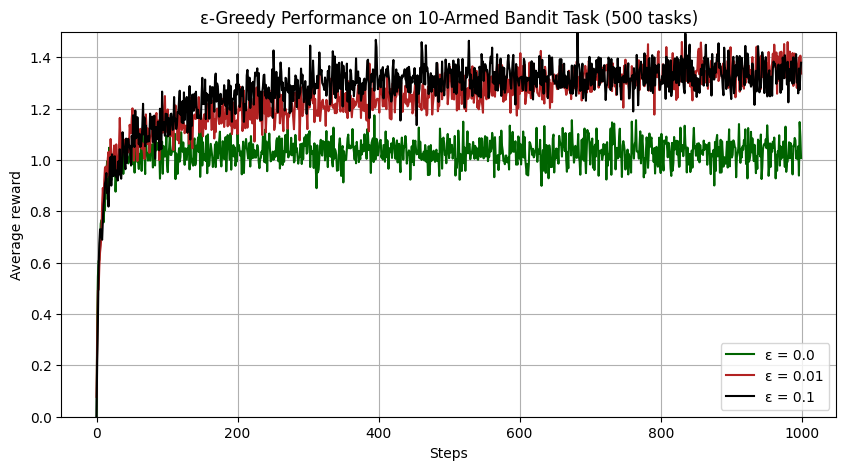

<function __main__.run_simulation(n_bandits, n_arms, n_steps, eps1, eps2, eps3)>

In [4]:
widgets.interact(
    run_simulation,

    n_bandits=widgets.IntSlider(
        value=500,
        min=100,
        max=2000,
        step=100,
        description='Bandits:'
    ),

    n_arms=widgets.IntSlider(
        value=10,
        min=2,
        max=50,
        step=1,
        description='Arms:'
    ),

    n_steps=widgets.IntSlider(
        value=1000,
        min=100,
        max=3000,
        step=100,
        description='Steps:'
    ),

    eps1=widgets.FloatSlider(
        value=0.0,
        min=0,
        max=1,
        step=0.01,
        description='Epsilon 1:'
    ),

    eps2=widgets.FloatSlider(
        value=0.01,
        min=0,
        max=1,
        step=0.01,
        description='Epsilon 2:'
    ),

    eps3=widgets.FloatSlider(
        value=0.1,
        min=0,
        max=1,
        step=0.01,
        description='Epsilon 3:'
    )
)